# Neural Network

Neural Networks are a machine learning model that learns the parameters to represent the training data, uncovering patterns in the data.

Import the libraries

In [1]:
import numpy as np

%matplotlib ipympl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from celluloid import Camera
import scienceplots
from IPython.display import Image

np.random.seed(0)
plt.style.use(["science", "no-latex"])

In [2]:
from abc import ABC, abstractmethod


class Layer(ABC):
    def __init__(self):
        self.input = None
        self.output = None

    @abstractmethod
    def forward(self, input):
        pass

    @abstractmethod
    def backward(self, output_gradient, learning_rate):
        pass

## Forward Propagation

![Neural Network](plot/nn.svg)

$
\begin{align*}
Z_1 &= W_1 X + B_1 \\
A_1 &= tanh(Z_1) \\
Z_2 &= W_2 A_1 + B_2 \\
A_2 &= tanh(Z_2) \\
Z_3 &= W_3 A_2 + B_3 \\
\hat{y} &= A_3 = tanh(Z_3)
\end{align*}
$

## Backpropagation

Backpropagation is the process of updating all of the weights and biases using the chain rule and gradient descent. After one pass of backpagation, the weights and biases will be updated using:

$
\begin{align*}
W_1 &= W_1 - \eta \\
B_1 &= B_1 - \eta \\
W_2 &= W_2 - \eta \\
B_2 &= B_2 - \eta \\
W_3 &= W_3 - \eta \\
B_3 &= B_3 - \eta
\end{align*}
$

## Dense Layers

In [3]:
class Dense(Layer):
    def __init__(self, input_neurons, output_neurons):
        self.weights = np.random.randn(output_neurons, input_neurons)
        self.bias = np.random.randn(output_neurons, 1)

    def forward(self, input):
        self.input = input
        return np.matmul(self.weights, self.input) + self.bias

    def backward(self, output_gradient, learning_rate):
        # Calculate gradients
        weights_gradient = np.matmul(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        # Gradient Descent
        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        return input_gradient

## Activation Function

### Tanh Function

$
\begin{align*}
\sigma(z) &= \frac{e^z-e^{-z}}{e^z+e^{-z}}
\end{align*}
$

### Tanh Gradinet

$
\begin{align*}
\sigma^\prime(z) &= \frac{\partial}{\partial z} [ \frac{e^z-e^{-z}}{e^z+e^{-z}} ] \\
&= 1 - [\sigma(z)]^2
\end{align*}
$

In [4]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

    def plot(self, x_min, x_max, points=25):
        x = np.linspace(x_min, x_max, points)
        y = self.activation(x)
        y_prime = self.activation_prime(y)

        fig, axes = plt.subplots(1, 2)
        axes[0].plot(x, y)
        axes[0].set_xlabel("X")
        axes[0].set_ylabel("Y")
        axes[0].set_title("F(X)")

        axes[1].plot(x, y_prime)
        axes[1].set_xlabel("X")
        axes[1].set_ylabel("Y")
        axes[1].set_title("F'(X)")

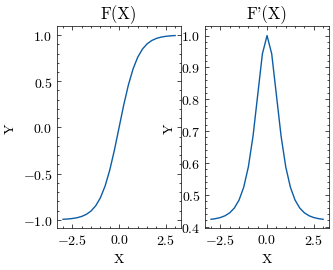

In [5]:
class Tanh(Activation):
    def __init__(self):
        tanh = lambda x: np.tanh(x)
        tanh_prime = lambda x: 1 - np.tanh(x) ** 2
        super().__init__(tanh, tanh_prime)


Tanh().plot(-3, 3)

In [6]:
class ArcTan(Activation):
    def __init__(self):
        arctan = lambda x: np.arctan(x)
        arctan_prime = lambda x: 1 / (1 + np.power(x, 2))
        super().__init__(arctan, arctan_prime)


class Sigmoid(Activation):
    def __init__(self):
        sigmoid = lambda x: 1 / (1 + np.exp(-x))
        sigmoid_prime = lambda x: np.exp(-x) / np.power((1 + np.exp(-x)), 2)
        super().__init__(sigmoid, sigmoid_prime)


class Relu(Activation):
    def __init__(self):
        relu = lambda x: np.maximum(0, x)
        relu_prime = lambda x: np.greater(x, 0).astype(int)
        super().__init__(relu, relu_prime)


class LeakyRelu(Activation):
    def __init__(self):
        relu = lambda x: np.where(x > 0, x, x * 0.1)
        relu_prime = lambda x: np.where(x > 0, 1, 0.01)
        super().__init__(relu, relu_prime)

## Loss Function 
The loss function is needed to evaluate the performance of the model and to update the weights accordingly.

### Mean Squared Error
Quadratic loss functions, like mean squared error, are used for regression tasks, like this example.

$ J = \frac{1}{n} \sum_{i=1}^{n}(y_{i}-\hat{y})^2 $

In [7]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

### Mean Squared Error Gradient
In order to perform backpropagation to update the weights, we need to calculate the gradient of the loss function.

$
\begin{align*}
J^{\prime} &= \frac{\partial}{\partial \hat{y}} [ \frac{1}{n} \sum_{i=1}^{n}(y_{i}-\hat{y})^2 ] \\
&= \frac{1}{n} \sum_{i=1}^{n}\frac{\partial}{\partial \hat{y}} [ (y_{i}-\hat{y})^2 ] \\
&= \frac{2}{n} \sum_{i=1}^{n} (y_{i}-\hat{y}) \frac{\partial}{\partial \hat{y}}[y_{i}-\hat{y}] \\
&= \frac{2}{n} \sum_{i=1}^{n} (y_{i}-\hat{y}) (-1) \\
&= \frac{2}{n} \sum_{i=1}^{n}(\hat{y}-y_{i})
\end{align*}
$

In [8]:
def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

## Training Dataset

The neural network will learn the parameters to fit a Hyperbolic Paraboloid.

$
\begin{align*}
z &= \frac{y^2}{b^2} - \frac{x^2}{a^2}
\end{align*}
$

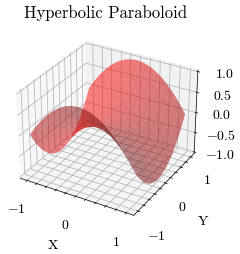

In [9]:
def generate_function(dims):
    a = 1
    b = 1

    # Hyperbolic Paraboloid
    x = np.linspace(-1, 1, dims)
    y = np.linspace(-1, 1, dims)
    X, Y = np.meshgrid(x, y)
    Z = (Y**2 / b**2) - (X**2 / a**2)

    X_t = X.flatten()
    Y_t = Y.flatten()
    Z_t = Z.flatten()
    X_t = X_t.reshape((len(X_t), 1))
    Y_t = Y_t.reshape((len(Y_t), 1))
    Z_t = Z_t.reshape((len(Z_t), 1))
    features = np.stack((X_t, Y_t), axis=1)
    labels = Z_t.reshape((len(Z_t), 1, 1))

    return X, Y, Z, features, labels


dims = 20
X, Y, Z, features, labels = generate_function(dims)

# Visualize the Hyperbolic Paraboloid
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, color="red", alpha=0.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Hyperbolic Paraboloid")
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from celluloid import Camera
from IPython.display import display, Latex, Image


def create_plots():
    fig, ax = plt.subplots(1, 3, figsize=(16 / 9.0 * 4, 4 * 1), layout="constrained")
    fig.suptitle("Neural Network")

    ax[0].set_xlabel("Epoch", fontweight="normal")
    ax[0].set_ylabel("Error", fontweight="normal")
    ax[0].set_title("Mean Squared Error")

    ax[1].axis("off")
    ax[2].axis("off")

    ax[2] = fig.add_subplot(1, 2, 2, projection="3d")
    ax[2].set_xlabel("X")
    ax[2].set_ylabel("Y")
    ax[2].set_zlabel("Z")
    ax[2].set_title("Function Approximation")
    ax[2].view_init(20, -35)
    ax[2].set_zlim(-1, 1)
    ax[2].axis("equal")

    camera = Camera(fig)
    return ax[0], ax[2], camera

## Training the model

In [11]:
def fit(
    network, features, labels, X, Y, Z, dims, epochs, learning_rate, output_filename
):
    mse_idx = np.arange(1, epochs + 1)
    errors = np.full(epochs, -1)
    ax0, ax1, camera = create_plots()

    for idx in range(epochs):
        error = 0
        predictions = np.array([])

        for x, y in zip(features, labels):
            # Forward Propagation
            output = x
            for layer in network:
                output = layer.forward(output)

            predictions = np.append(predictions, output)

            # Store Error
            error += mse(y, output)

            # Backpropagation
            grad = mse_prime(y, output)
            for layer in reversed(network):
                grad = layer.backward(grad, learning_rate)

        error /= len(X)

        if (
            idx < 5
            or (idx < 15 and idx % 2 == 0)
            or (idx <= 50 and idx % 10 == 0)
            or (idx <= 1000 and idx % 20 == 0)
            or idx % 250 == 0
        ):

            print(f"epoch: {idx}, MSE: {error}")

            # Plot MSE
            errors[idx] = error
            visible_mse = errors != -1
            ax0.plot(
                mse_idx[visible_mse][: idx + 1],
                errors[visible_mse][: idx + 1],
                color="red",
                alpha=0.5,
            )

            # Plot Neural Network Function Approximation
            # Ground truth
            ground_truth_legend = ax1.plot_surface(
                X, Y, Z, color="red", alpha=0.5, label="Ground Truth"
            )
            # Neural Network Predictions
            predictions_legend = ax1.scatter(
                X,
                Y,
                predictions.reshape((dims, dims)),
                color="blue",
                alpha=0.2,
                label="Prediction",
            )
            ax1.legend(
                (ground_truth_legend, predictions_legend),
                ("Ground Truth", "Predictions"),
                loc="upper left",
            )

            camera.snap()

    animation = camera.animate()
    animation.save(output_filename, writer="pillow")
    plt.show()

In [12]:
model = [Dense(2, 12), Tanh(), Dense(12, 4), Tanh(), Dense(4, 1), Tanh()]

The model can be visualized with the following:

<img src="plot/architecture/nn-1.png" alt="Fully Connected Neural Network" width="400" />

epoch: 0, MSE: 21.00860848511376
epoch: 1, MSE: 17.5586476607417
epoch: 2, MSE: 11.962836688096
epoch: 3, MSE: 7.68257809360996
epoch: 4, MSE: 5.856178734359532
epoch: 6, MSE: 4.101981960799444
epoch: 8, MSE: 3.239212598337815
epoch: 10, MSE: 2.781463458914172
epoch: 12, MSE: 2.4899978448083546
epoch: 14, MSE: 2.264408395525184
epoch: 20, MSE: 1.746794685353164
epoch: 30, MSE: 1.23779838600893
epoch: 40, MSE: 0.9715469061310487
epoch: 50, MSE: 0.8070032878502758
epoch: 60, MSE: 0.6957056202886597
epoch: 80, MSE: 0.5583020760768337
epoch: 100, MSE: 0.47836451995070384
epoch: 120, MSE: 0.4256256408272474
epoch: 140, MSE: 0.3874577766812147
epoch: 160, MSE: 0.35803563178169423
epoch: 180, MSE: 0.3343283017491935
epoch: 200, MSE: 0.3145830966011098


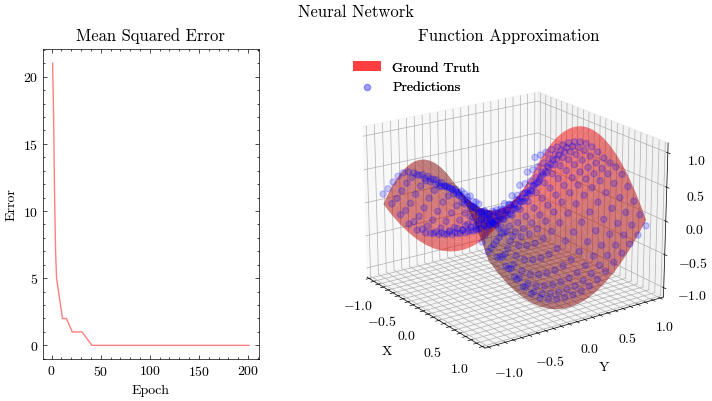

In [13]:
epochs = 201
learning_rate = 0.0005

output_filename = "neural_network.gif"
fit(model, features, labels, X, Y, Z, dims, epochs, learning_rate, output_filename)

## Output GIF

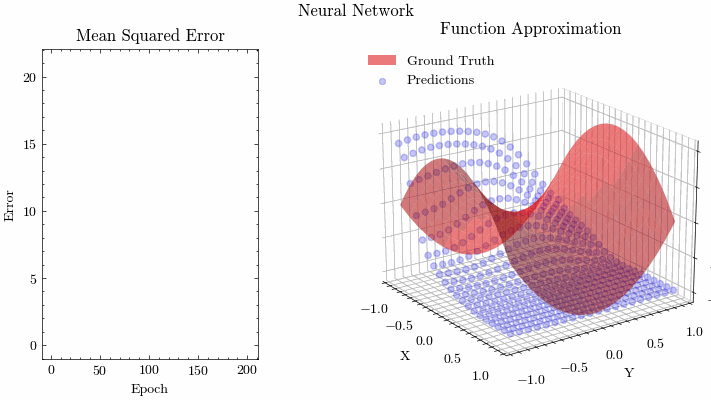

In [14]:
Image(filename=output_filename)

## Pytorch Implementation

Machine Learning libraries, such as PyTorch, provide utilities to easily train and test neural networks on all types of optimized hardware. Now we will implement the same network in PyTorch.

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

In PyTorch, we can visualize the data passing through the different layers and activation functions. Because PyTorch has built-in auto-differentiation, the backpropagation steps just involve calling an optimizer class and zeroing the gradients.

In [16]:
class TorchNet(nn.Module):
    def __init__(self):
        super(TorchNet, self).__init__()

        # define the layers
        self.fc1 = nn.Linear(2, 14)
        self.fc2 = nn.Linear(14, 4)
        self.fc3 = nn.Linear(4, 1)

    def forward(self, x):
        # pass the result of the previous layer to the next layer
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        return F.tanh(self.fc3(x))

In [17]:
def torch_fit(
    model, features, labels, X, Y, Z, dims, epochs, learning_rate, output_filename
):
    mse_idx = np.arange(1, epochs + 1)
    errors = np.full(epochs, -1)
    ax0, ax1, camera = create_plots()

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.0)

    for idx in range(epochs):
        error = 0
        predictions = np.array([])

        for x, y in zip(features, labels):
            # Forward Propagation
            output = model(x)

            output_np = output.detach().numpy()
            predictions = np.append(predictions, output_np)

            # Store Error
            loss = loss_fn(output, y)

            error += loss.detach().numpy()

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        error /= len(X)

        if (
            idx < 5
            or (idx < 15 and idx % 2 == 0)
            or (idx <= 50 and idx % 10 == 0)
            or (idx <= 1000 and idx % 20 == 0)
            or idx % 250 == 0
        ):

            print(f"epoch: {idx}, MSE: {error}")

            # Plot MSE
            errors[idx] = error
            visible_mse = errors != -1
            ax0.plot(
                mse_idx[visible_mse][: idx + 1],
                errors[visible_mse][: idx + 1],
                color="red",
                alpha=0.5,
            )

            # Plot Neural Network Function Approximation
            # Ground truth
            ground_truth_legend = ax1.plot_surface(
                X, Y, Z, color="red", alpha=0.5, label="Ground Truth"
            )
            # Neural Network Predictions
            predictions_legend = ax1.scatter(
                X,
                Y,
                predictions.reshape((dims, dims)),
                color="blue",
                alpha=0.2,
                label="Prediction",
            )
            ax1.legend(
                (ground_truth_legend, predictions_legend),
                ("Ground Truth", "Predictions"),
                loc="upper left",
            )

            camera.snap()

    animation = camera.animate()
    animation.save(output_filename, writer="pillow")
    plt.show()

epoch: 0, MSE: 6.654341220855713
epoch: 1, MSE: 4.935229301452637
epoch: 2, MSE: 4.469925403594971
epoch: 3, MSE: 4.367236137390137
epoch: 4, MSE: 4.3388214111328125
epoch: 6, MSE: 4.31099796295166
epoch: 8, MSE: 4.2904767990112305
epoch: 10, MSE: 4.275124549865723
epoch: 12, MSE: 4.263519287109375
epoch: 14, MSE: 4.25434684753418
epoch: 20, MSE: 4.233529090881348
epoch: 30, MSE: 4.200819492340088
epoch: 40, MSE: 4.157847881317139
epoch: 50, MSE: 4.098803520202637
epoch: 60, MSE: 4.017776966094971
epoch: 80, MSE: 3.751148223876953
epoch: 100, MSE: 3.2569472789764404
epoch: 120, MSE: 2.526139736175537
epoch: 140, MSE: 1.8032686710357666
epoch: 160, MSE: 1.1914664506912231
epoch: 180, MSE: 0.6603571176528931
epoch: 200, MSE: 0.3379576802253723
epoch: 220, MSE: 0.21674802899360657
epoch: 240, MSE: 0.18050765991210938
epoch: 250, MSE: 0.17289552092552185
epoch: 260, MSE: 0.16786618530750275
epoch: 280, MSE: 0.16101498901844025
epoch: 300, MSE: 0.15574774146080017
epoch: 320, MSE: 0.1511127

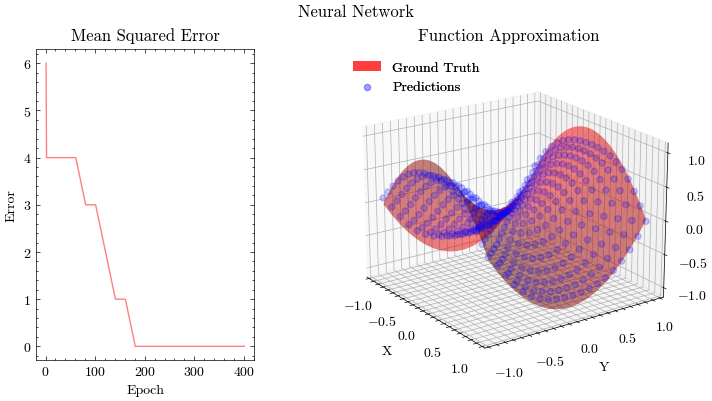

In [18]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch_model = TorchNet().to(device)

# the inputs and outputs for PyTorch must be tensors
features_tensor = torch.tensor(features, device=device, dtype=torch.float32).squeeze(-1)
labels_tensor = torch.tensor(labels, device=device, dtype=torch.float32).squeeze(-1)

epochs = 401
learning_rate = 0.0005

output_filename_pytorch = "neural_network_pytorch.gif"
torch_fit(
    torch_model,
    features_tensor,
    labels_tensor,
    X,
    Y,
    Z,
    dims,
    epochs,
    learning_rate,
    output_filename_pytorch,
)

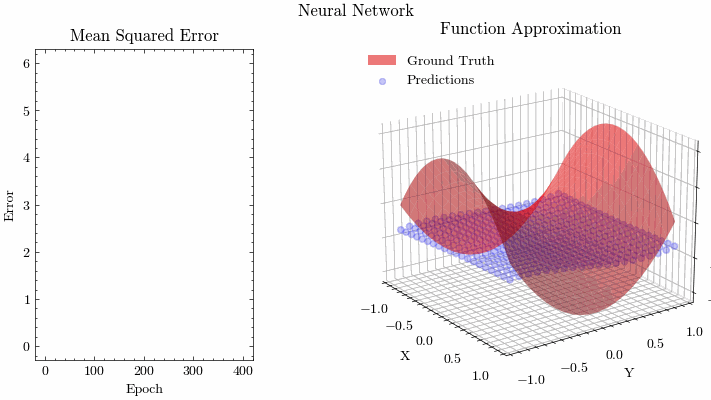

In [19]:
Image(filename=output_filename_pytorch)